## Initial imports

In [1]:
import scm.plams as plams
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import AllChem
from typing import List, Tuple

IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = 250, 250

# this line is not required in AMS2025+
plams.init()

PLAMS working folder: /path/plams/examples/MoleculeSubstitution/plams_workdir


## Helper class and function

The ``MoleculeConnector`` class and ``substitute()`` method below are convenient to use.

In [2]:
class MoleculeConnector:
    def __init__(self, molecule, connector, name="molecule"):
        self.name = name
        self.molecule = molecule
        self.molecule.properties.name = name
        self.connector = connector  # 2-tuple of integers, unlike the Molecule.substitute() method which uses two atoms

    def __str__(self):
        return f"""
Name: {self.name}
{self.molecule}
Connector: {self.connector}. This means that when substitution is performed atom {self.connector[0]} will be kept in the substituted molecule. Atom {self.connector[1]}, and anything connected to it, will NOT be kept.
        """


def substitute(substrate: MoleculeConnector, ligand: MoleculeConnector):
    """
    Returns: Molecule with the ligand added to the substrate, replacing the respective connector bonds.
    """
    molecule = substrate.molecule.copy()
    molecule.substitute(
        connector=(molecule[substrate.connector[0]], molecule[substrate.connector[1]]),
        ligand=ligand.molecule,
        ligand_connector=(ligand.molecule[ligand.connector[0]], ligand.molecule[ligand.connector[1]]),
    )
    return molecule


def set_atom_indices(rdmol: Chem.rdchem.Mol, start=0):
    for atom in rdmol.GetAtoms():
        atom.SetAtomMapNum(atom.GetIdx() + start)  # give 1-based index
    return rdmol


def to_lewis(molecule: plams.Molecule, template=None, regenerate: bool = True):
    if isinstance(molecule, Chem.rdchem.Mol):
        rdmol = molecule
    else:
        rdmol = plams.to_rdmol(molecule)
    if regenerate:
        rdmol = Chem.RemoveHs(rdmol)
        smiles = Chem.MolToSmiles(rdmol)
        rdmol = Chem.MolFromSmiles(smiles)
    if template is not None:
        AllChem.GenerateDepictionMatching2DStructure(rdmol, template)
    try:
        if molecule.properties.name:
            rdmol.SetProp("_Name", molecule.properties.name)
    except AttributeError:
        pass
    return rdmol


def smiles2template(smiles: str):
    template = Chem.MolFromSmiles(smiles)
    AllChem.Compute2DCoords(template)
    return template


def draw_lewis_grid(
    molecules: List[plams.Molecule],
    molsPerRow: int = 4,
    template_smiles: str = None,
    regenerate: bool = False,
    draw_atom_indices: bool = False,
    draw_legend: bool = True,
):
    template = None
    if template_smiles:
        template = smiles2template(template_smiles)

    rdmols = [to_lewis(x, template=template, regenerate=regenerate) for x in molecules]
    if draw_atom_indices:
        for rdmol in rdmols:
            set_atom_indices(rdmol, start=1)
    legends = None
    if draw_legend:
        try:
            legends = [x.properties.name or f"mol{i}" for i, x in enumerate(molecules)]
        except AttributeError:
            pass

    return Draw.MolsToGridImage(rdmols, molsPerRow=molsPerRow, legends=legends)


def view_molecules(molecules: List[plams.Molecule], titles: List[str], figsize: Tuple[int], **kwargs):
    fig, axes = plt.subplots(1, len(molecules), figsize=figsize)
    if len(molecules) == 1:
        axes = [axes]
    try:
        from scm.plams import view  # view molecule using AMSview in a Jupyter Notebook in AMS2026+

        imgs = [view(m, **kwargs) for m in molecules]
        for ax, img, title in zip(axes, imgs, titles):
            ax.imshow(img)
            ax.axis("off")
            ax.set_title(title)
        plt.show()
    except ImportError:
        from scm.plams import plot_molecule  # plot molecule in a Jupyter Notebook in AMS2023+

        for ax, mol, title in zip(axes, molecules, titles):
            plot_molecule(mol, ax=ax)
            ax.set_title(title)


def view_molecule(molecule: plams.Molecule, title: str, figsize: Tuple[int] = (8, 8), **kwargs):
    view_molecules([molecule], [title], figsize, **kwargs)

## Generate substrate molecule

In [3]:
substrate_smiles = "c1ccccc1"
substrate = plams.from_smiles(substrate_smiles, forcefield="uff")
substrate.properties.name = "benzene"

## Find out which bond to cleave

In the molecule you need to define which bond to cleave. To find out the bonds, run for example:

In [4]:
for b in substrate.bonds:
    el1 = b.atom1.symbol
    el2 = b.atom2.symbol
    idx1, idx2 = substrate.index(b)
    print(f"{el1}({idx1})--{el2}({idx2})")

C(1)--C(2)
C(2)--C(3)
C(3)--C(4)
C(4)--C(5)
C(5)--C(6)
C(6)--C(1)
C(1)--H(7)
C(2)--H(8)
C(3)--H(9)
C(4)--H(10)
C(5)--H(11)
C(6)--H(12)


to find that atoms 6 (C) and 12 (H) are bonded. We will choose this bond to cleave.

Alternatively, we can inspect the molecule inside a Jupyter notebook, visualizing with AMSView, to also find that atoms 6 (C) and 12 (H) are bonded.

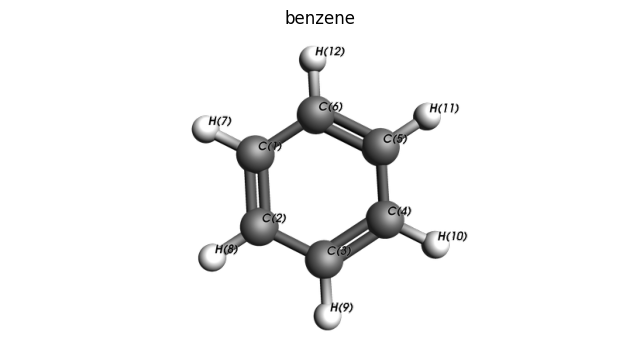

In [5]:
view_molecule(substrate, substrate.properties.name, padding=-0.5, show_atom_labels=True, atom_label_type="Name")

In [6]:
substrate_connector = MoleculeConnector(
    substrate, (6, 12), "phenyl"
)  # benzene becomes phenyl when bond between atoms 6,12 is cleaved

## Define ligands

Perform the same steps for the ligands.

**Note**: The ligands below have an extra hydrogen  or even more atoms compared to the name that they're given.

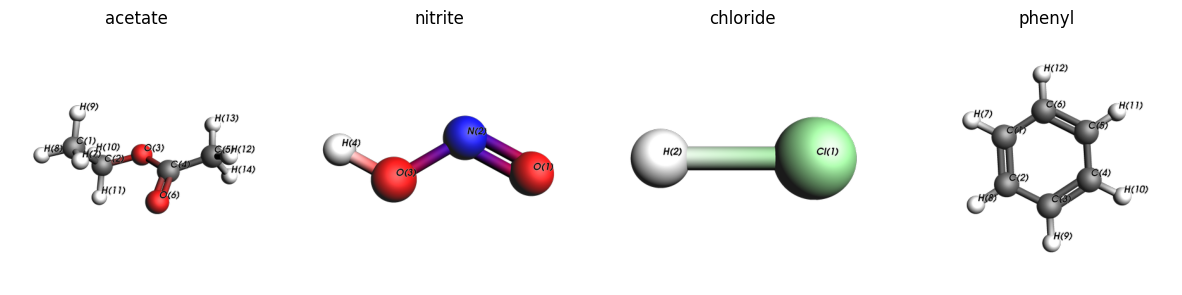

In [7]:
ligands = [
    MoleculeConnector(
        plams.from_smiles("CCOC(=O)C", forcefield="uff"), (3, 2), "acetate"
    ),  # ethyl acetate, bond from O to C cleaved
    MoleculeConnector(
        plams.from_smiles("O=NO", forcefield="uff"), (3, 4), "nitrite"
    ),  # nitrous acid, bond from O to H cleaved
    MoleculeConnector(
        plams.from_smiles("Cl", forcefield="uff"), (1, 2), "chloride"
    ),  # hydrogen chloride, bond from Cl to H cleaved
    MoleculeConnector(
        plams.from_smiles("c1ccccc1", forcefield="uff"), (6, 12), "phenyl"
    ),  # benzene, bond to C to H cleaved
]

ligand_molecules = [ligand.molecule for ligand in ligands]

view_molecules(
    ligand_molecules,
    [ligand.name for ligand in ligands],
    figsize=(15, 4),
    width=400,
    show_atom_labels=True,
    atom_label_type="Name",
)

Above we see that cleaving the bonds from O(3)-C(2), O(3)-H(4), Cl(1)-H(2), and C(6)-H(12) will give the acetate, nitrite, chloride, and phenyl substituents, respectively.

## Generate substituted molecules

In [8]:
mols = []

for ligand in ligands:
    mol = substitute(substrate_connector, ligand)
    mol.properties.name = f"{substrate_connector.name}--{ligand.name}"
    mols.append(mol)
    print(f"Writing {mol.properties.name}.xyz")
    mol.write(f"{mol.properties.name}.xyz")
    print(f"{mol.properties.name} formula: {mol.get_formula(as_dict=True)}")

Writing phenyl--acetate.xyz
phenyl--acetate formula: {'C': 8, 'H': 8, 'O': 2}
Writing phenyl--nitrite.xyz
phenyl--nitrite formula: {'C': 6, 'H': 5, 'O': 2, 'N': 1}
Writing phenyl--chloride.xyz
phenyl--chloride formula: {'C': 6, 'H': 5, 'Cl': 1}
Writing phenyl--phenyl.xyz
phenyl--phenyl formula: {'C': 12, 'H': 10}


## Plot 3D structures with PLAMS

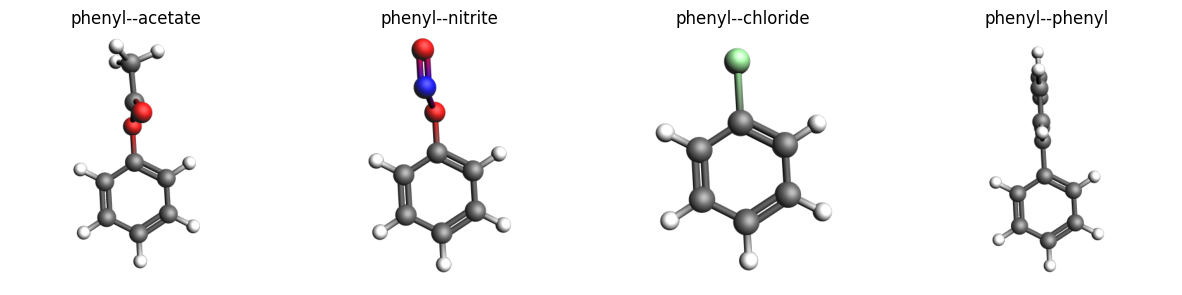

In [9]:
view_molecules(mols, [mol.properties.name for mol in mols], figsize=(15, 4), width=400, padding=-0.3)

## Plot 2D Lewis structures with RDKit

The molecules can be aligned by using a benzene template. The ``regenerate`` option regenerates the molecule with RDkit to clean up the atomic positions.

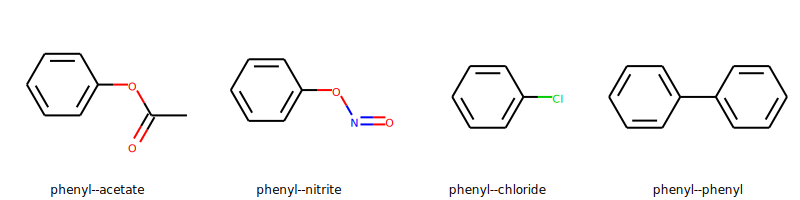

In [10]:
draw_lewis_grid(mols, template_smiles=substrate_smiles, regenerate=True)